# Clustering Track

**Problem statement.** Segment hotel bookings into groups of similar customers using only what is
known when the booking is made, with no labels during fitting. A hotel that knows which kinds of
booking it receives, and in what proportions, can tailor pricing, deposit rules and marketing to each
group instead of treating 85,000 bookings as one population.

**Dataset.** `data/hotel_bookings.csv`, 119,390 bookings x 32 columns, from Antonio, Almeida & Nunes
(2019), *Hotel booking demand datasets*, Data in Brief 22:41-49. This is the same dataset, and after
cleaning the same 85,693 rows, as the regression track.

**Unsupervised discipline.** `is_canceled` and `hotel` are available as reference labels. `is_canceled` is
set aside before any model sees the data and is used only in section 9, to interpret and sanity-check
the clusters after the fact.

**Notebook map** (rubric references in brackets):

| Section | Contents | Rubric |
|---|---|---|
| 1 | Load & audit | A1 |
| 2 | Exploratory data analysis | A2, A3 |
| 3 | Cleaning | B1 |
| 4 | Feature engineering | B3 |
| 5 | Encoding, scaling, splitting, PCA structure | B2 |
| 6 | K-Means (elbow) and Agglomerative (dendrogram, linkages) | B1, B2 |
| 7 | Comparative evaluation: Silhouette, Davies-Bouldin, Calinski-Harabasz, stability | B2 |
| 8 | Cluster visualisation: PCA 2D and t-SNE | B3 |
| 9 | Cluster profiling and external validation | - |
| 10 | Conclusion | - |

In [ ]:
import time
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

sns.set_theme(style="whitegrid", palette="colorblind")
plt.rcParams["figure.dpi"] = 110
pd.set_option("display.width", 120)
pd.set_option("display.max_columns", 40)

warnings.filterwarnings("ignore", category=FutureWarning)

DATA = "../data/hotel_bookings.csv"

## 1. Load & audit  *(A1)*

In [ ]:
df_raw = pd.read_csv(DATA)
print(f"rows: {df_raw.shape[0]:,}    columns: {df_raw.shape[1]}")
df_raw.head()

rows: 119,390    columns: 32


,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,children,babies,meal,country,market_segment,distribution_channel,is_repeated_guest,previous_cancellations,previous_bookings_not_canceled,reserved_room_type,assigned_room_type,booking_changes,deposit_type,agent,company,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date
0,Resort Hotel,0,342,2015,July,27,1,0,0,2,0.0,0,BB,PRT,Direct,Direct,0,0,0,C,C,3,No Deposit,NaN,NaN,0,Transient,0.0,0,0,Check-Out,2015-07-01
1,Resort Hotel,0,737,2015,July,27,1,0,0,2,0.0,0,BB,PRT,Direct,Direct,0,0,0,C,C,4,No Deposit,NaN,NaN,0,Transient,0.0,0,0,Check-Out,2015-07-01
2,Resort Hotel,0,7,2015,July,27,1,0,1,1,0.0,0,BB,GBR,Direct,Direct,0,0,0,A,C,0,No Deposit,NaN,NaN,0,Transient,75.0,0,0,Check-Out,2015-07-02
3,Resort Hotel,0,13,2015,July,27,1,0,1,1,0.0,0,BB,GBR,Corporate,Corporate,0,0,0,A,A,0,No Deposit,304.0,NaN,0,Transient,75.0,0,0,Check-Out,2015-07-02
4,Resort Hotel,0,14,2015,July,27,1,0,2,2,0.0,0,BB,GBR,Online TA,TA/TO,0,0,0,A,A,0,No Deposit,240.0,NaN,0,Transient,98.0,0,1,Check-Out,2015-07-03


In [ ]:
audit = pd.DataFrame({
    "dtype": df_raw.dtypes.astype(str),
    "missing": df_raw.isna().sum(),
    "missing_%": (df_raw.isna().mean() * 100).round(2),
    "unique": df_raw.nunique(),
})
audit

,dtype,missing,missing_%,unique
hotel,str,0,0.00,2
is_canceled,int64,0,0.00,2
lead_time,int64,0,0.00,479
arrival_date_year,int64,0,0.00,3
arrival_date_month,str,0,0.00,12
arrival_date_week_number,int64,0,0.00,53
arrival_date_day_of_month,int64,0,0.00,31
stays_in_weekend_nights,int64,0,0.00,17
stays_in_week_nights,int64,0,0.00,35
adults,int64,0,0.00,14


In [ ]:
# Reference labels. They are inspected here and then set aside: they are used
# only AFTER clustering, to interpret and sanity-check the clusters.
print("Reference label 1 - is_canceled")
print(df_raw["is_canceled"].value_counts().rename({0: "kept", 1: "cancelled"}).to_frame("bookings")
      .assign(share=lambda d: (d["bookings"] / len(df_raw) * 100).round(1)))
print("\nReference label 2 - hotel")
print(df_raw["hotel"].value_counts().to_frame("bookings")
      .assign(share=lambda d: (d["bookings"] / len(df_raw) * 100).round(1)))
print(f"\nexact duplicate rows (ignoring is_canceled): "
      f"{df_raw.drop(columns='is_canceled').duplicated().sum():,}")

Reference label 1 - is_canceled
             bookings  share
is_canceled                 
kept            75166   63.0
cancelled       44224   37.0

Reference label 2 - hotel
              bookings  share
hotel                        
City Hotel       79330   66.4
Resort Hotel     40060   33.6



exact duplicate rows (ignoring is_canceled): 31,994


**Observation.** 119,390 bookings and 32 columns. Four columns have gaps and they are missing for different
reasons: `company` is 94.3% empty, `agent` 13.7%, `country` 0.4% and `children` only 4 rows. Section 3.2 gives
each its own treatment.

The reference label `is_canceled` is 37.0% cancelled, and two thirds of the bookings are City Hotel. Neither label is
extremely imbalanced, so neither will dominate the picture by itself. 31,994 rows (26.8%) are exact duplicates
once the label is ignored; they matter more for clustering than for most tasks, because repeated identical points
pull centroids toward themselves, and are dealt with in section 3.3.

## 2. Exploratory data analysis  *(A2, A3)*

### 2.1 Reference-label distribution

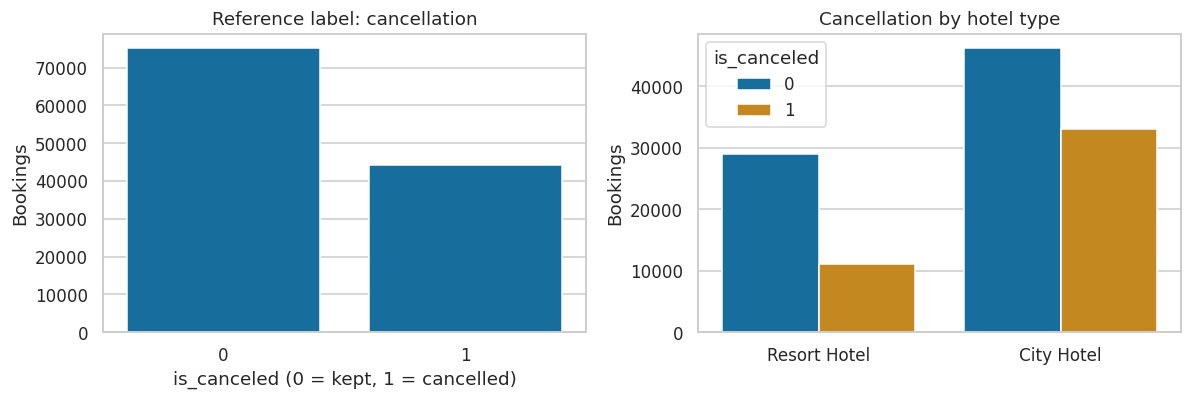

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(11, 3.8))
sns.countplot(data=df_raw, x="is_canceled", ax=axes[0])
axes[0].set(title="Reference label: cancellation", xlabel="is_canceled (0 = kept, 1 = cancelled)",
            ylabel="Bookings")
sns.countplot(data=df_raw, x="hotel", hue="is_canceled", ax=axes[1])
axes[1].set(title="Cancellation by hotel type", xlabel="", ylabel="Bookings")
axes[1].legend(title="is_canceled")
plt.tight_layout()
plt.show()

**Observation.** The reference label is a 63/37 split, and cancellation depends strongly on the hotel: 41.7% of City
Hotel bookings are cancelled against 27.8% at the Resort. This is the first hint that any segmentation
that separates customer types might also separate cancellation risk, which section 9 tests. Neither label is
given to the algorithms.

### 2.2 Distributions of the numeric features

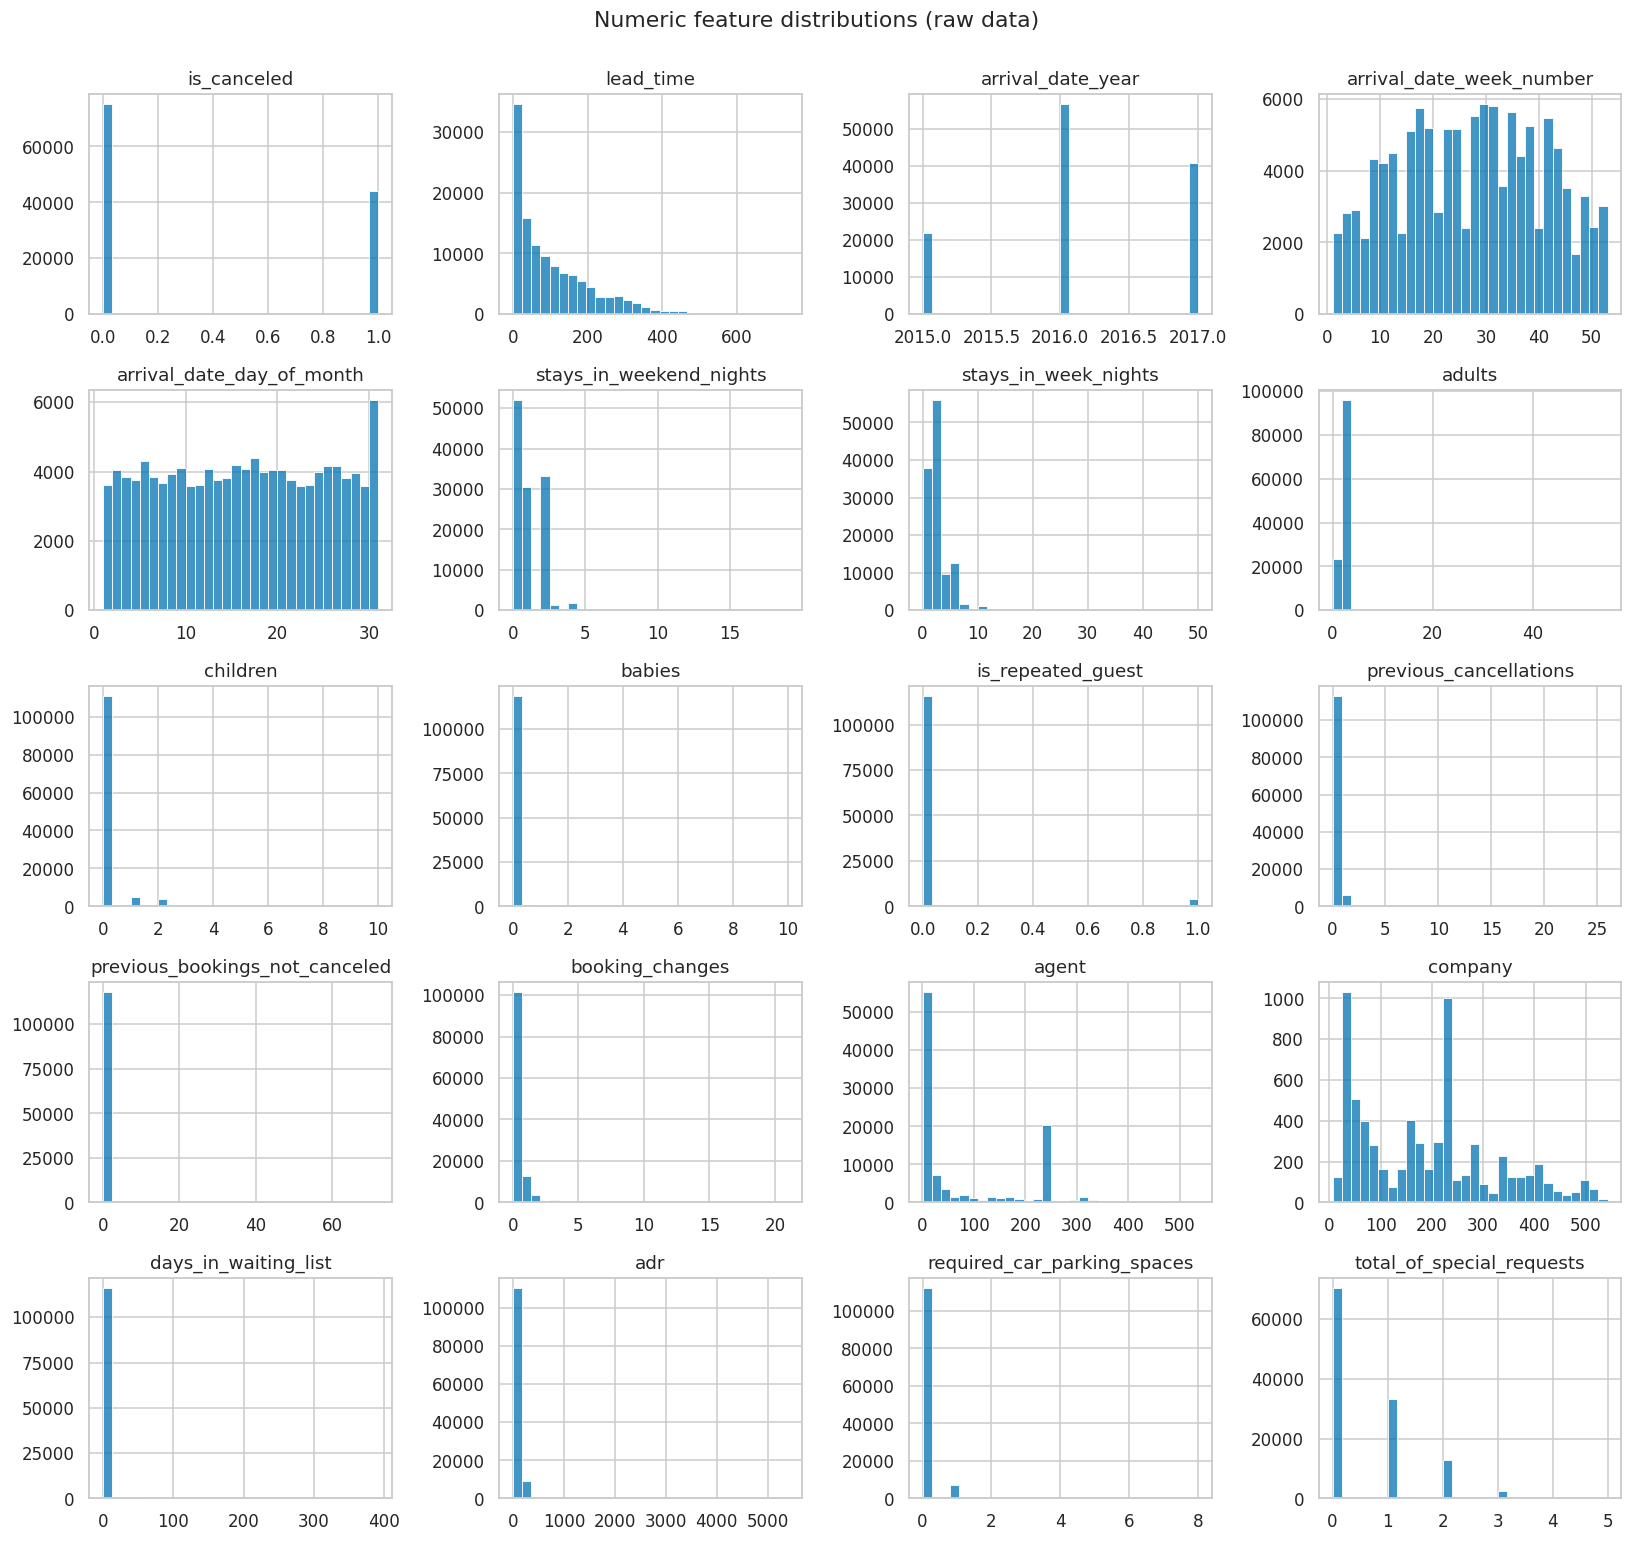

In [ ]:
numeric_raw = df_raw.select_dtypes("number").columns
fig, axes = plt.subplots(5, 4, figsize=(15, 14))
for ax, col in zip(axes.ravel(), numeric_raw):
    sns.histplot(df_raw[col], bins=30, ax=ax)
    ax.set(title=col, xlabel="", ylabel="")
for ax in axes.ravel()[len(numeric_raw):]:
    ax.set_visible(False)
fig.suptitle("Numeric feature distributions (raw data)", y=1.0)
plt.tight_layout()
plt.show()

**Observation.** Most numeric columns are zero-inflated or heavily right-skewed. 84.9% of bookings have no booking
changes, 93.8% need no parking space, 94.6% have no previous cancellations, 96.8% are not repeat guests and 96.9%
never waited on a waiting list. `lead_time` has a median of 69 days but a 90th percentile of 265 and a maximum of 737.

Two consequences. First, the features live on very different scales, so unscaled Euclidean distance would be decided by
`lead_time` and `days_in_waiting_list` alone, and scaling is mandatory. Second, a standard scaler does not cure a long
tail: a booking 700 days ahead would still sit many standard deviations out and could attract a centroid of its own.
Section 4 therefore log-transforms the skewed columns before scaling. The date columns (`arrival_date_year`,
`arrival_date_day_of_month`) say nothing about customer type and are left out of the clustering features.

### 2.3 Correlation structure

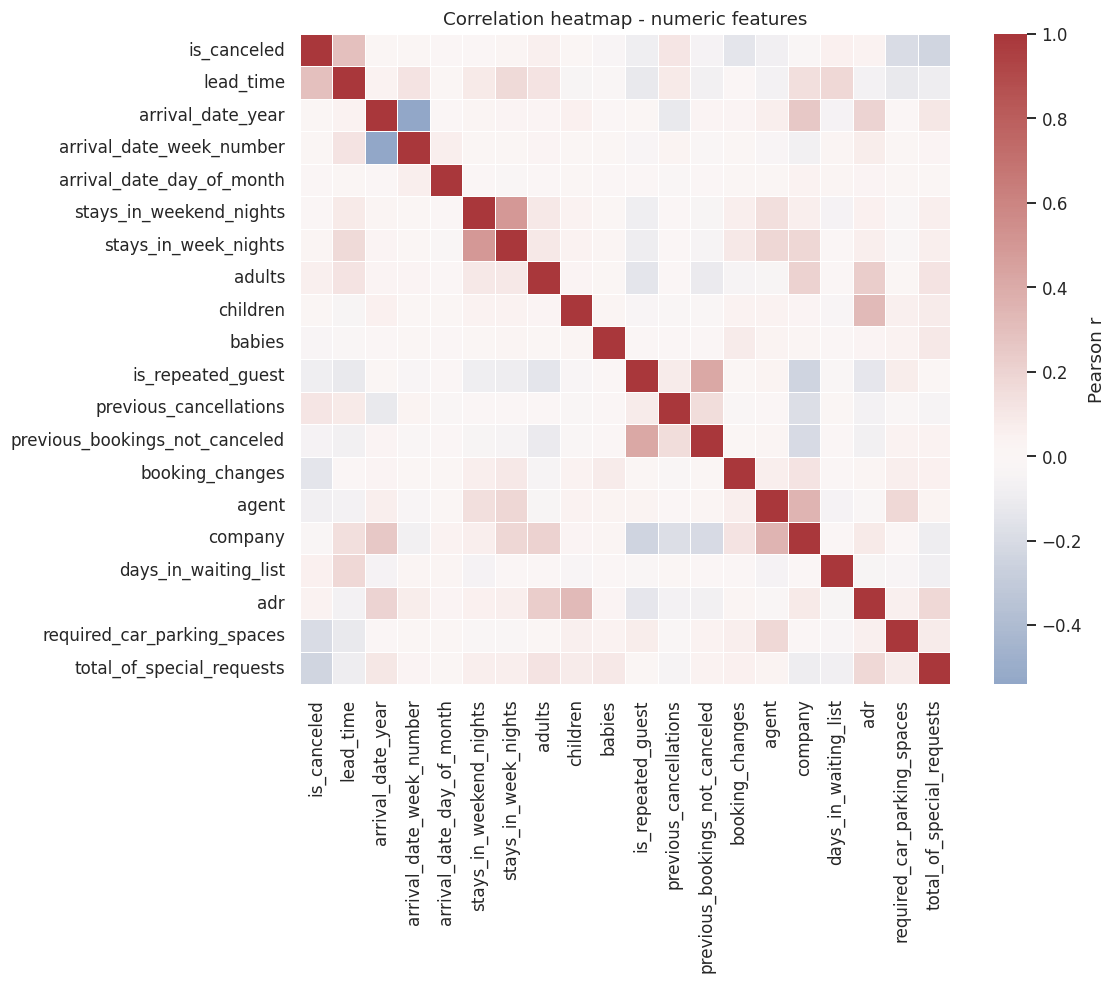

Strongest feature-feature correlations:
arrival_date_year        arrival_date_week_number         -0.541
stays_in_weekend_nights  stays_in_week_nights              0.499
is_repeated_guest        previous_bookings_not_canceled    0.418
agent                    company                           0.351
children                 adr                               0.325
is_canceled              lead_time                         0.293
arrival_date_year        company                           0.259
is_repeated_guest        company                          -0.245


In [ ]:
corr = df_raw.select_dtypes("number").corr()
fig, ax = plt.subplots(figsize=(11, 9))
sns.heatmap(corr, cmap="vlag", center=0, annot=False, square=True,
            linewidths=.4, cbar_kws={"label": "Pearson r"}, ax=ax)
ax.set_title("Correlation heatmap - numeric features")
plt.tight_layout()
plt.show()

pairs = (corr.where(np.triu(np.ones(corr.shape, dtype=bool), k=1)).stack()
         .sort_values(key=abs, ascending=False).head(8).round(3))
print("Strongest feature-feature correlations:")
print(pairs.to_string())

**Observation.** No pair of numeric features is strongly correlated. The largest, `arrival_date_year` with
`arrival_date_week_number` at r = -0.54, is an artefact of the data covering July 2015 to August 2017 rather than complete
years. The next, weekend nights with week nights (0.50) and `is_repeated_guest` with `previous_bookings_not_canceled`
(0.42), are two views of one idea each, so section 4 merges them into `total_nights` and `prev_total`.

The strongest link to the reference label is `lead_time` at r = 0.29: cancelled bookings were made a median of 113 days
ahead against 45 for kept ones. Nothing in the feature-feature correlations alone suggests clean cluster structure, so
the later internal indices are what has to tell us whether groups exist.

### 2.4 Pairwise relationships

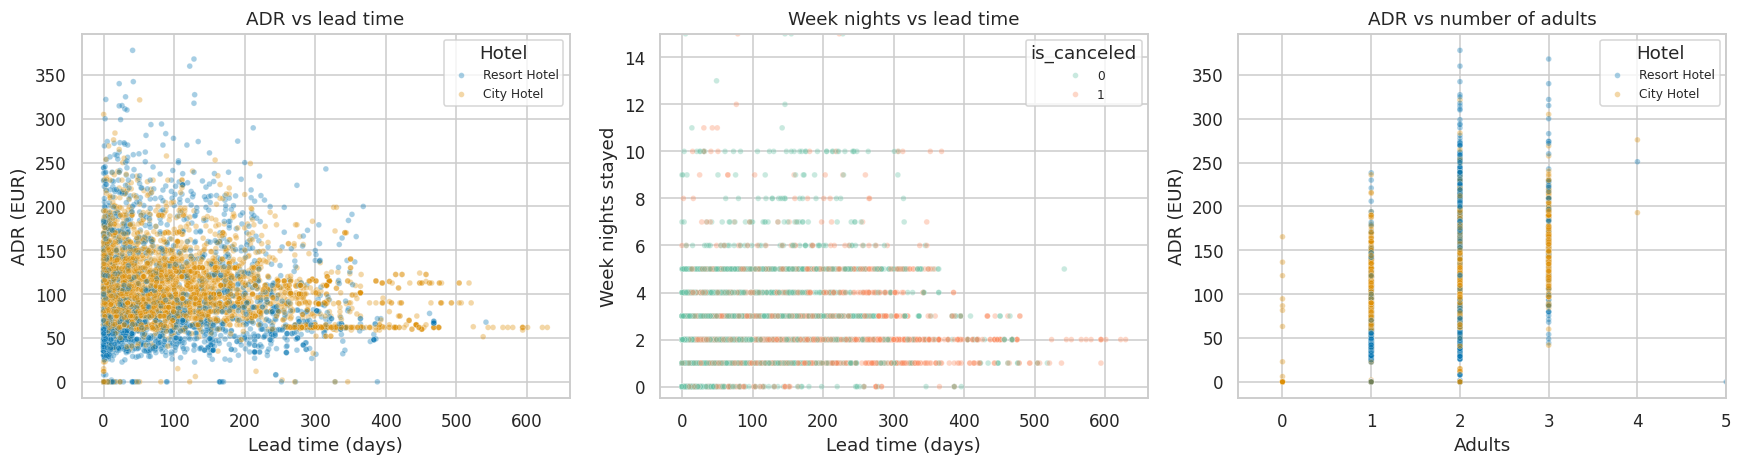

In [ ]:
sample = df_raw.sample(6000, random_state=RANDOM_STATE)
sample = sample[sample["adr"].between(0, 400)]
fig, axes = plt.subplots(1, 3, figsize=(16, 4.4))

sns.scatterplot(data=sample, x="lead_time", y="adr", hue="hotel",
                alpha=.35, s=14, ax=axes[0])
axes[0].set(title="ADR vs lead time", xlabel="Lead time (days)", ylabel="ADR (EUR)")
axes[0].legend(title="Hotel", fontsize=8)

sns.scatterplot(data=sample, x="lead_time", y="stays_in_week_nights", hue="is_canceled",
                alpha=.35, s=14, palette="Set2", ax=axes[1])
axes[1].set(title="Week nights vs lead time", xlabel="Lead time (days)",
            ylabel="Week nights stayed", ylim=(-0.5, 15))
axes[1].legend(title="is_canceled", fontsize=8)

sns.scatterplot(data=sample, x="adults", y="adr", hue="hotel",
                alpha=.35, s=14, ax=axes[2])
axes[2].set(title="ADR vs number of adults", xlabel="Adults", ylabel="ADR (EUR)", xlim=(-0.5, 5))
axes[2].legend(title="Hotel", fontsize=8)

plt.tight_layout()
plt.show()

**Observation.** The raw feature space is a single dense cloud with no visible gaps. In the first panel almost all bookings sit
below roughly 150 days of lead time and between EUR 50 and 150; the very long lead times form a thin tail made mostly of City
Hotel bookings at a flat rate near EUR 60, which looks like a contracted or negotiated price. The second panel shows cancelled bookings (orange) spreading further to the right,
consistent with the r = 0.29 above, but they are mixed through the same area as kept bookings, so no two raw features
separate the label on their own. Whatever structure exists must come from combinations of features, which is the reason to use
a multivariate method.

### 2.5 Categorical structure

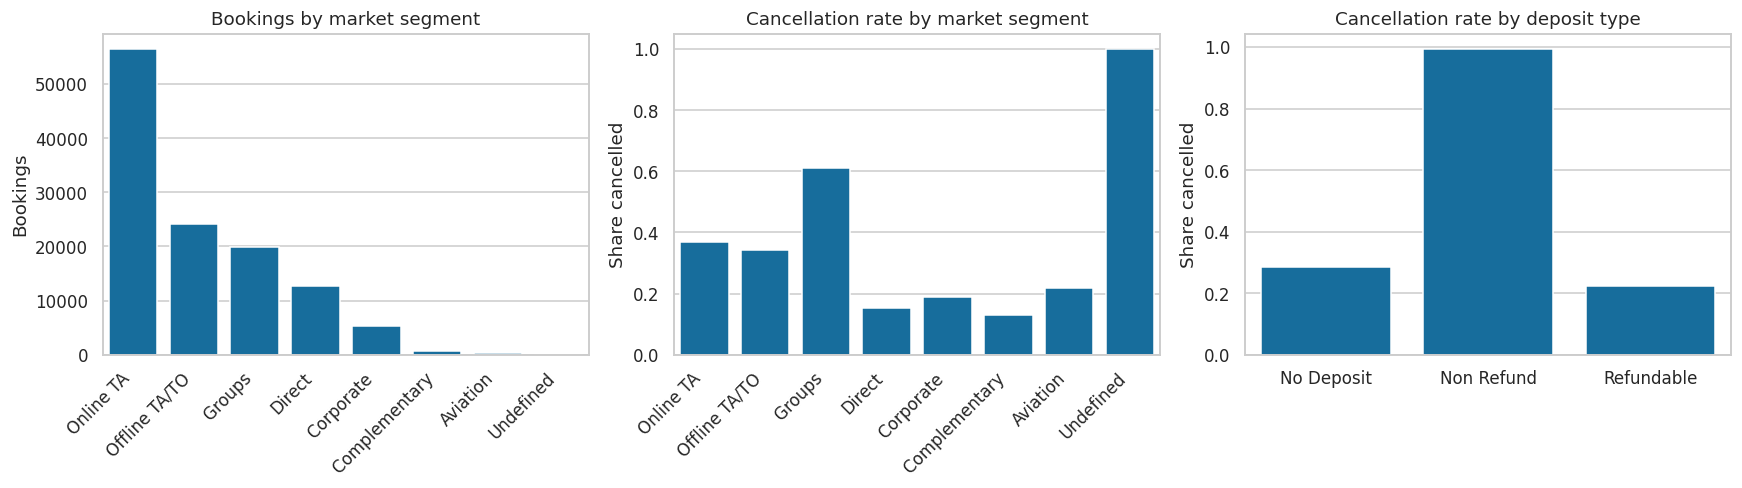

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4.6))

seg = df_raw.groupby("market_segment")["is_canceled"].agg(["size", "mean"]).sort_values("size", ascending=False)
sns.barplot(x=seg.index, y=seg["size"], ax=axes[0])
axes[0].set(title="Bookings by market segment", xlabel="", ylabel="Bookings")
axes[0].tick_params(axis="x", rotation=45)
for lbl in axes[0].get_xticklabels():
    lbl.set_ha("right")

sns.barplot(x=seg.index, y=seg["mean"], ax=axes[1])
axes[1].set(title="Cancellation rate by market segment", xlabel="", ylabel="Share cancelled")
axes[1].tick_params(axis="x", rotation=45)
for lbl in axes[1].get_xticklabels():
    lbl.set_ha("right")

dep = df_raw.groupby("deposit_type")["is_canceled"].agg(["size", "mean"])
sns.barplot(x=dep.index, y=dep["mean"], ax=axes[2])
axes[2].set(title="Cancellation rate by deposit type", xlabel="", ylabel="Share cancelled")
plt.tight_layout()
plt.show()

**Observation.** Market segment is the most informative categorical. Online travel agents provide the most bookings (56,477) at a
36.7% cancellation rate, Groups cancel 61.1% of the time, while Direct (15.3%) and Corporate (18.7%) bookings rarely cancel.
Deposit type has the famous quirk: the 14,587 `Non Refund` bookings cancel 99.4% of the time against 28.4% for `No Deposit`, which
is counter-intuitive and probably reflects how the hotels recorded no-shows and group blocks; it should not be read as a customer
trait. Because this is behaviour that segments describe, `market_segment`, `distribution_channel`, `deposit_type` and
`customer_type` are all kept as clustering features.

## 3. Cleaning  *(B1)*

The cleaning rules are identical to the regression track, so both tracks work on
the same 85,693 bookings. The only difference is in what gets dropped and why.

### 3.1 Columns that cannot be used

In [ ]:
# Clustering has no prediction moment, but the clusters should still describe a
# booking as it stands when it is made. Columns settled later would describe the
# outcome instead of the customer, and the segments would be trivially "cancelled"
# versus "not cancelled".
DROPPED = {
    "reservation_status":      "outcome: check-out / cancelled / no-show",
    "reservation_status_date": "the date that outcome was set",
    "assigned_room_type":      "the room actually given, decided at check-in",
    "is_canceled":             "reference label - kept aside, never used to fit",
}
ref_all = df_raw["is_canceled"].copy()          # aligned to df_raw's index
df = df_raw.drop(columns=list(DROPPED))
for col, why in DROPPED.items():
    print(f"set aside  {col:24s}  {why}")
print(f"\ncolumns: {df_raw.shape[1]} -> {df.shape[1]}")

set aside  reservation_status        outcome: check-out / cancelled / no-show
set aside  reservation_status_date   the date that outcome was set
set aside  assigned_room_type        the room actually given, decided at check-in
set aside  is_canceled               reference label - kept aside, never used to fit

columns: 32 -> 28


**Observation.** `reservation_status` and its date are the outcome of the booking, `assigned_room_type` is decided at check-in, and
`is_canceled` is the reference label. If any of these went into the feature matrix, the clusters would simply recover the
outcome, and the later comparison with `is_canceled` would be circular. Setting them aside keeps the segmentation about the
customer and the evaluation about something the model never saw.

### 3.2 Missing values

In [ ]:
# company: 94.3% missing - the id is useless, the presence of a company is a signal.
df["has_company"] = df["company"].notna().astype(int)
df = df.drop(columns=["company"])

# agent: blank means "booked without a travel agent" - informative absence.
df["has_agent"] = df["agent"].notna().astype(int)
df["agent"] = df["agent"].fillna(0).astype(int).astype(str)   # kept ONLY so de-duplication matches the regression track;
                                                               # the 334-level id is not used as a clustering feature

# children: 4 rows; a missing count means no children were declared.
df["children"] = df["children"].fillna(0)

# country: 0.4% genuinely unknown - own level rather than a mode fill.
df["country"] = df["country"].fillna("Unknown")

# meal: "Undefined" and "SC" both mean no meal package (Antonio et al. 2019).
df["meal"] = df["meal"].replace({"Undefined": "SC"})

print(f"remaining missing values: {df.isna().sum().sum()}")
print(f"has_company = 1 : {df['has_company'].mean() * 100:5.2f}%")
print(f"has_agent   = 1 : {df['has_agent'].mean() * 100:5.2f}%")

remaining missing values: 0
has_company = 1 :  5.69%
has_agent   = 1 : 86.31%


**Observation.** Nothing got a mean or mode fill. `company` and `agent` are mostly structural absences, so each becomes a 0/1 flag
(5.69% of bookings have a company; 86.31% used an agent), and the agent id is kept as a column only so that de-duplication
in 3.3 treats rows exactly as the regression track does. `country` keeps an explicit `Unknown` level, `children` gets 0 for its 4 gaps,
and `meal` merges `Undefined` into `SC` because they mean the same thing.

### 3.3 Invalid rows, duplicates and outliers

In [ ]:
rows = [("raw", len(df))]

df = df[df["adr"].between(0, 1000)]
rows.append(("after ADR range filter", len(df)))

df = df[(df["adults"] + df["children"] + df["babies"]) > 0]
rows.append(("after zero-guest filter", len(df)))

# De-duplicate WITHOUT is_canceled in the frame (as in the regression track), so that
# exactly the same rows survive. The index is kept so the reference label can be
# re-attached afterwards.
df = df.drop_duplicates()
rows.append(("after de-duplication", len(df)))

ref = pd.DataFrame({"is_canceled": ref_all.loc[df.index]})
df = df.reset_index(drop=True)
ref = ref.reset_index(drop=True)

log = pd.DataFrame(rows, columns=["stage", "rows"])
log["removed"] = -log["rows"].diff().fillna(0).astype(int)
log["% of raw"] = (log["rows"] / rows[0][1] * 100).round(1)
print(f"clean dataset: {df.shape[0]:,} rows x {df.shape[1]} columns")
log

clean dataset: 85,693 rows x 29 columns


,stage,rows,removed,% of raw
0,raw,119390,0,100.0
1,after ADR range filter,119388,2,100.0
2,after zero-guest filter,119208,180,99.8
3,after de-duplication,85693,33515,71.8


**Observation.** The same three filters as the regression track leave 85,693 rows. The two impossible rates (-EUR 6.40 and EUR 5,400)
and 180 zero-guest bookings go, along with 33,515 duplicates (28% of the data).

For clustering the duplicate filter matters more than it did for regression. Without it, each repeated group or corporate booking
would be counted many times and would pull centroids toward itself. A side effect is worth knowing: the reference
cancellation rate falls from 37.0% to 27.6% after cleaning, which means the removed duplicates were disproportionately
cancelled bookings, so the cleaned dataset under-represents repeated group cancellations. Bookings with `adr = 0` (about 1.9%) are
kept as complimentary or staff stays.

In [ ]:
# Outlier check on the features we will actually cluster on
q = df[["lead_time", "adr", "stays_in_week_nights", "stays_in_weekend_nights",
        "adults", "children", "babies", "booking_changes", "days_in_waiting_list"]]
pd.DataFrame({"99th pct": q.quantile(.99), "99.9th pct": q.quantile(.999), "max": q.max()}).round(1)

,99th pct,99.9th pct,max
lead_time,344.0,479.0,737.0
adr,262.0,335.0,510.0
stays_in_week_nights,10.0,19.0,50.0
stays_in_weekend_nights,4.0,7.0,19.0
adults,3.0,3.0,55.0
children,2.0,2.0,10.0
babies,1.0,1.0,10.0
booking_changes,3.0,6.0,18.0
days_in_waiting_list,0.0,160.6,391.0


**Observation.** The tails are far beyond the bulk: `adults` has a 99.9th percentile of 3 but a maximum of 55, `lead_time` reaches 737 days
against a 99th percentile of 344, and `days_in_waiting_list` is 0 at the 99th percentile yet reaches 391. These are real
bookings (a coach group, a 2-year advance reservation) rather than errors, so they are kept but tamed: party size is capped at 6 and the
long-tailed columns are log-transformed in section 4. Dropping them would remove the very bookings that form small distinct segments.

## 4. Feature engineering  *(B3)*

In [ ]:
MONTHS = ["January", "February", "March", "April", "May", "June", "July",
          "August", "September", "October", "November", "December"]

# Party composition: one rate per room, so who is in it matters.
df["total_guests"] = df["adults"] + df["children"] + df["babies"]
df["is_family"]    = ((df["children"] + df["babies"]) > 0).astype(int)

# Stay length and its weekend share - a weekend break and a business week are
# different customers with the same number of nights.
df["total_nights"]  = df["stays_in_weekend_nights"] + df["stays_in_week_nights"]
df["weekend_ratio"] = (df["stays_in_weekend_nights"] / df["total_nights"].replace(0, np.nan)).fillna(0)

# Seasonality as a circle, so week 52 and week 1 are neighbours.
df["week_sin"] = np.sin(2 * np.pi * df["arrival_date_week_number"] / 52)
df["week_cos"] = np.cos(2 * np.pi * df["arrival_date_week_number"] / 52)

# Guest history: two views of one underlying quantity.
df["prev_total"] = df["previous_cancellations"] + df["previous_bookings_not_canceled"]

# Origin: Portugal is the home market for both hotels.
df["is_domestic"] = (df["country"] == "PRT").astype(int)

# Winsorise party size: a handful of group bookings of 20-55 would dominate any
# distance-based method.
df["guests_capped"] = df["total_guests"].clip(upper=6)

# log1p for the heavy right tails seen in section 2.2. Distance-based clustering
# is dominated by whichever feature has the longest tail.
for col, new in [("lead_time", "log_lead_time"), ("total_nights", "log_nights"),
                 ("adr", "log_adr"), ("booking_changes", "log_changes"),
                 ("prev_total", "log_prev"), ("days_in_waiting_list", "log_waiting")]:
    df[new] = np.log1p(df[col])

NEW = ["total_guests", "is_family", "total_nights", "weekend_ratio", "week_sin", "week_cos",
       "prev_total", "is_domestic", "guests_capped", "log_lead_time", "log_nights", "log_adr",
       "log_changes", "log_prev", "log_waiting"]
print(f"{len(NEW)} engineered features")
df[NEW].describe().T.round(3)

15 engineered features


,count,mean,std,min,25%,50%,75%,max
total_guests,85693.0,2.035,0.792,1.0,2.000,2.000,2.000,55.000
is_family,85693.0,0.106,0.308,0.0,0.000,0.000,0.000,1.000
total_nights,85693.0,3.644,2.752,0.0,2.000,3.000,5.000,69.000
weekend_ratio,85693.0,0.264,0.280,0.0,0.000,0.250,0.400,1.000
week_sin,85693.0,-0.008,0.712,-1.0,-0.749,-0.000,0.749,1.000
week_cos,85693.0,-0.143,0.687,-1.0,-0.823,-0.239,0.465,1.000
prev_total,85693.0,0.218,1.925,0.0,0.000,0.000,0.000,78.000
is_domestic,85693.0,0.311,0.463,0.0,0.000,0.000,1.000,1.000
guests_capped,85693.0,2.031,0.704,1.0,2.000,2.000,2.000,6.000
log_lead_time,85693.0,3.521,1.628,0.0,2.485,3.912,4.828,6.604


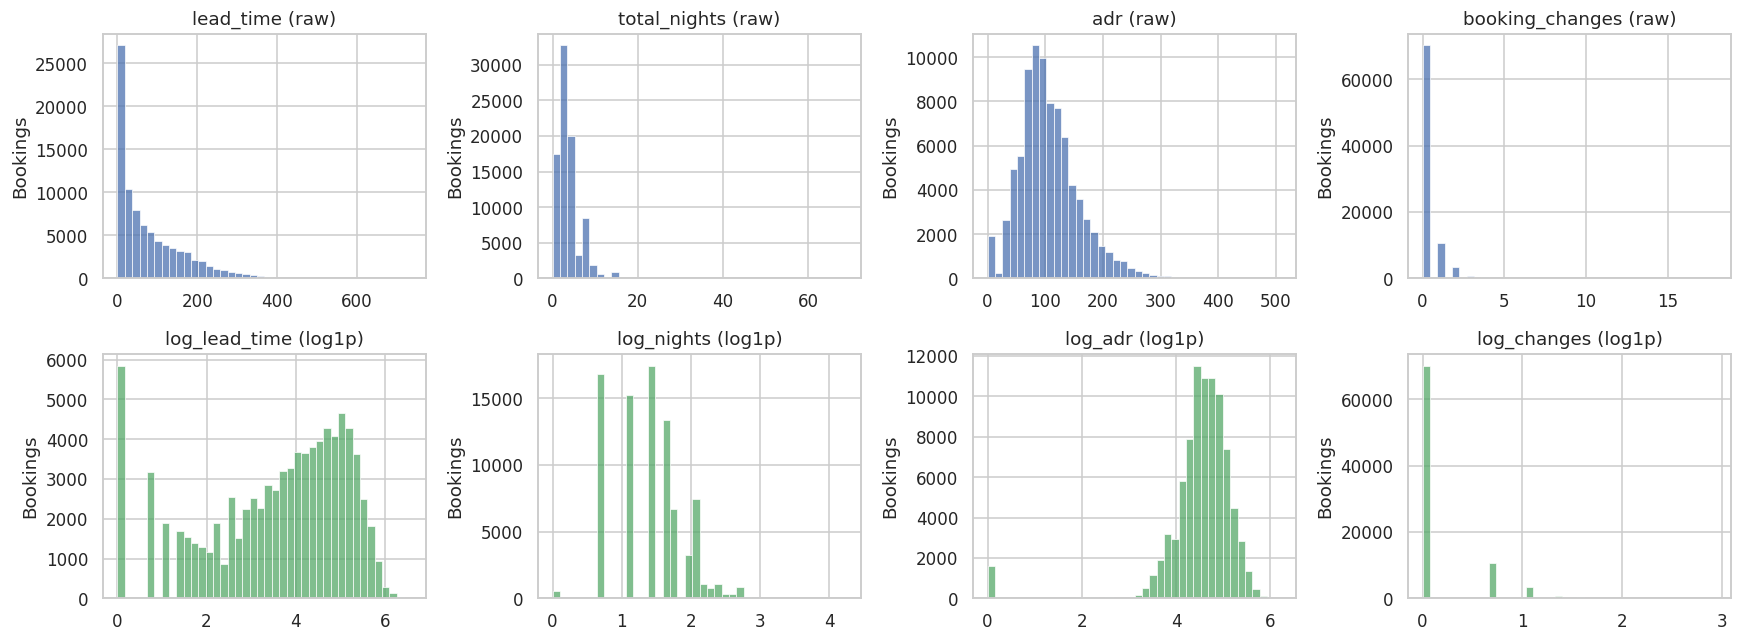

,raw skew,transformed skew
lead_time -> log_lead_time,1.44,-0.71
total_nights -> log_nights,2.93,0.22
adr -> log_adr,0.87,-3.57
booking_changes -> log_changes,5.07,2.25
prev_total -> log_prev,19.89,6.43
days_in_waiting_list -> log_waiting,21.58,11.46
total_guests -> guests_capped,10.62,0.88


In [ ]:
from scipy.stats import skew

pairs = [("lead_time", "log_lead_time"), ("total_nights", "log_nights"), ("adr", "log_adr"),
         ("booking_changes", "log_changes"), ("prev_total", "log_prev"),
         ("days_in_waiting_list", "log_waiting"), ("total_guests", "guests_capped")]
skew_tbl = pd.DataFrame({"raw skew": [skew(df[a]) for a, _ in pairs],
                         "transformed skew": [skew(df[b]) for _, b in pairs]},
                        index=[f"{a} -> {b}" for a, b in pairs]).round(2)

fig, axes = plt.subplots(2, 4, figsize=(16, 6))
for j, (a, b) in enumerate(pairs[:4]):
    sns.histplot(df[a], bins=40, ax=axes[0, j], color="#4C72B0")
    axes[0, j].set(title=f"{a} (raw)", xlabel="", ylabel="Bookings")
    sns.histplot(df[b], bins=40, ax=axes[1, j], color="#55A868")
    axes[1, j].set(title=f"{b} (log1p)", xlabel="", ylabel="Bookings")
plt.tight_layout()
plt.show()
skew_tbl

**Observation.** The log transform does what it is meant to for the main features. `lead_time` skew falls from 1.44 to -0.71, `total_nights` from
2.93 to 0.22, and capping party size takes `total_guests` from 10.62 to 0.88. The mostly-zero columns improve but stay skewed
(`prev_total` 19.89 to 6.43, `days_in_waiting_list` 21.57 to 11.46), which is expected for features that are zero for 95%+ of rows;
they behave like rare flags and will matter only for the few bookings where they fire.

One transform made things worse: `adr` goes from 0.87 to -3.57. The 1,959 `adr = 0` rows become `log1p(0) = 0`, a left tail that
sits about 5.7 standard deviations below the mean. We keep it, since complimentary stays are a legitimate kind of booking
and the left tail is a genuine feature of the data. The engineered features are justified in the code comments: party composition
(`is_family`, `guests_capped`), stay shape (`log_nights`, `weekend_ratio`), cyclical seasonality (`week_sin`, `week_cos`), guest history (`prev_total`)
and origin (`is_domestic`).

## 5. Encoding, scaling & splitting  *(B2)*

### 5.1 Choosing the clustering feature set

Clustering uses Euclidean distance, so every redundant column silently double-counts a
concept. We keep one representation of each idea: the log-transformed versions of the
skewed features, the engineered party/seasonality features, and six low-cardinality
categoricals. High-cardinality columns (`country`, `agent`, `reserved_room_type`) are
reduced to flags or left out, because 20+ one-hot dummies would dominate the distance.

In [ ]:
NUM = ["log_lead_time", "log_nights", "weekend_ratio", "guests_capped", "is_family", "log_adr",
       "log_changes", "log_prev", "is_repeated_guest", "has_agent", "has_company",
       "required_car_parking_spaces", "total_of_special_requests", "log_waiting",
       "week_sin", "week_cos", "is_domestic"]
CAT = ["hotel", "meal", "market_segment", "distribution_channel", "deposit_type", "customer_type"]

features = df[NUM + CAT]
print(f"numeric features    : {len(NUM)}")
print(f"categorical features: {len(CAT)}  {CAT}")
print(f"levels per categorical: {features[CAT].nunique().to_dict()}")

numeric features    : 17
categorical features: 6  ['hotel', 'meal', 'market_segment', 'distribution_channel', 'deposit_type', 'customer_type']
levels per categorical: {'hotel': 2, 'meal': 4, 'market_segment': 8, 'distribution_channel': 5, 'deposit_type': 3, 'customer_type': 4}


### 5.2 Preprocessing pipeline and hold-out split

Clustering has no target, but we still keep a 20% hold-out. The preprocessor and every
clustering model are fitted on the training 80% only; the hold-out is used at the end to
ask whether the clusters generalise to bookings the model never saw. The split is
stratified on the reference label so both halves have the same cancellation rate; the
label plays no other part.

In [ ]:
from sklearn.compose import ColumnTransformer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler

F_train, F_test, ref_train, ref_test = train_test_split(
    features, ref, test_size=0.2, random_state=RANDOM_STATE, stratify=ref["is_canceled"])

preprocessor = ColumnTransformer([
    ("cat", OneHotEncoder(handle_unknown="ignore", sparse_output=False), CAT),
    ("num", StandardScaler(), NUM),
])

X_train = preprocessor.fit_transform(F_train)      # fitted on the training rows only
X_test = preprocessor.transform(F_test)
feature_names = [n.split("__", 1)[-1] for n in preprocessor.get_feature_names_out()]

print(f"model features after encoding: {X_train.shape[1]}")
print(f"train: {X_train.shape[0]:,} rows    hold-out: {X_test.shape[0]:,} rows")
print(f"cancellation rate  train {ref_train['is_canceled'].mean():.4f}   "
      f"hold-out {ref_test['is_canceled'].mean():.4f}")

model features after encoding: 43
train: 68,554 rows    hold-out: 17,139 rows
cancellation rate  train 0.2763   hold-out 0.2763


### 5.3 Working sample

Agglomerative clustering stores an n x n distance structure, so on 68,554 rows it needs
tens of gigabytes. Both algorithms are therefore **compared on the same fixed random sample
of 8,000 training rows**, which keeps the comparison fair. K-Means is later refitted on the
full training set (section 6.4) to confirm that nothing was lost by sampling.

In [ ]:
SAMPLE_N = 8000
rng = np.random.RandomState(RANDOM_STATE)
idx_s = rng.choice(len(X_train), SAMPLE_N, replace=False)
X_s = X_train[idx_s]
F_s = F_train.iloc[idx_s].reset_index(drop=True)
ref_s = ref_train.iloc[idx_s].reset_index(drop=True)

print(f"sample: {X_s.shape}    cancellation rate in sample {ref_s['is_canceled'].mean():.4f} "
      f"(train {ref_train['is_canceled'].mean():.4f})")

sample: (8000, 43)    cancellation rate in sample 0.2759 (train 0.2763)


**Observation.** 6 categoricals and 17 numerics become 43 model columns. The scaler and one-hot encoder are fitted on 68,554 training rows only, the
hold-out has 17,139, and both halves have an identical 27.63% reference cancellation rate, so the hold-out check in section 7.2 is a
fair test. The 8,000-row working sample is representative (27.59% cancelled against 27.63%).

### 5.4 How much structure is there? PCA of the feature space

80% of variance ->  12 of 43 components
90% of variance ->  16 of 43 components
95% of variance ->  19 of 43 components


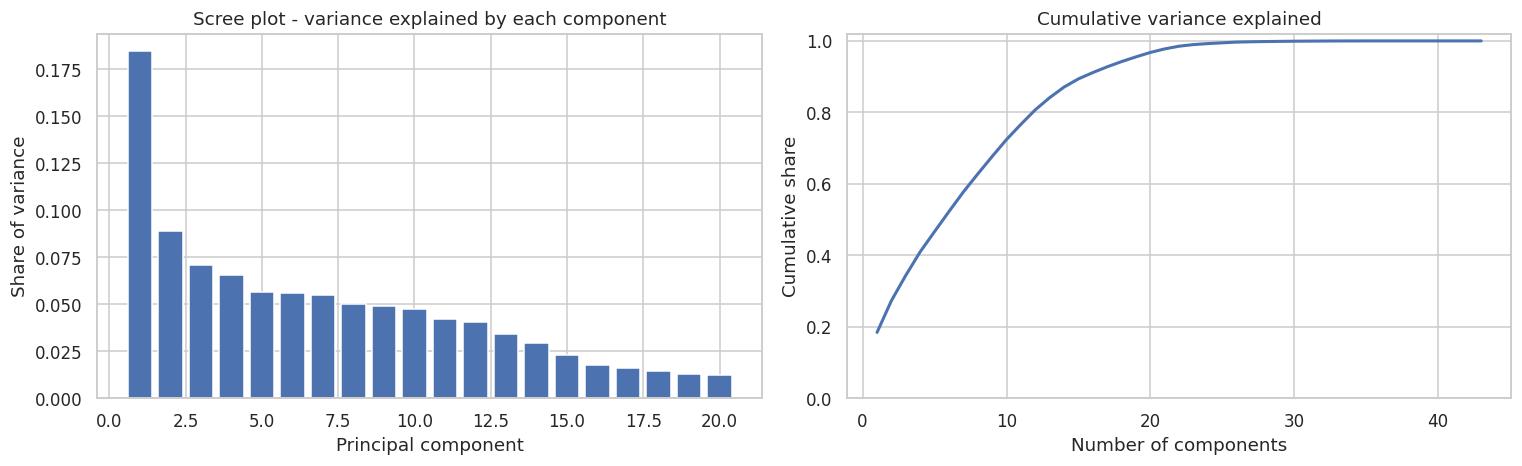

first two components: 27.4% of the variance


In [ ]:
from sklearn.decomposition import PCA

pca_full = PCA(random_state=RANDOM_STATE).fit(X_s)
cumulative = np.cumsum(pca_full.explained_variance_ratio_)
for threshold in (0.80, 0.90, 0.95):
    k = np.searchsorted(cumulative, threshold) + 1
    print(f"{int(threshold * 100)}% of variance -> {k:3d} of {X_s.shape[1]} components")

fig, axes = plt.subplots(1, 2, figsize=(14, 4.4))
axes[0].bar(range(1, 21), pca_full.explained_variance_ratio_[:20], color="#4C72B0")
axes[0].set(title="Scree plot - variance explained by each component",
            xlabel="Principal component", ylabel="Share of variance")
axes[1].plot(range(1, len(cumulative) + 1), cumulative, lw=2, color="#4C72B0")
axes[1].set(title="Cumulative variance explained", xlabel="Number of components",
            ylabel="Cumulative share", ylim=(0, 1.02))
plt.tight_layout()
plt.show()
print(f"first two components: {cumulative[1] * 100:.1f}% of the variance")

**Observation.** The variance is spread out. Twelve of the 43 components are needed for 80%, 16 for 90% and 19 for 95%, and the scree plot has
no elbow. The first two components carry only 27.4% (PC1 18.5%, PC2 8.9%).

This matters for section 8: a 2-D PCA picture hides almost three quarters of the variance, so clusters that overlap in the PCA plot
may still be separated in the 43 dimensions, and the internal indices, which use all 43, are the real test. This
is also why PCA is used here for visualisation only. Unlike in the regression track, where PCA discarded predictive signal, there is no
target here for it to damage, but the gradual scree says compressing before clustering would buy little.